<a href="https://colab.research.google.com/github/ZainabNizar/geneticdispred/blob/main/genetic_disorder_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import joblib

In [ ]:
data=pd.read_csv('/content/Genetic Disorder Prediction.csv')

In [ ]:
data.head()

,Patient Age,Genes in mother's side,Inherited from father,Maternal gene,Paternal gene,Blood cell count (mcL),Mother's age,Father's age,Respiratory Rate (breaths/min),Heart Rate (rates/min,...,Birth defects,White Blood cell count (thousand per microliter),Blood test result,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5,Genetic Disorder,Disorder Subclass
0,12.0,No,No,No,No,5.056471,34.0,NaN,Normal (30-60),Normal,...,Multiple,6.040263,slightly abnormal,1.0,1.0,1.0,0.0,NaN,Mitochondrial genetic inheritance disorders,Mitochondrial myopathy
1,7.0,Yes,Yes,NaN,Yes,5.056058,26.0,45.0,Normal (30-60),Normal,...,Singular,8.836764,normal,NaN,1.0,0.0,1.0,0.0,Single-gene inheritance diseases,NaN
2,1.0,Yes,No,Yes,Yes,5.147776,45.0,41.0,Normal (30-60),Tachycardia,...,Singular,9.921528,abnormal,1.0,1.0,1.0,NaN,1.0,Single-gene inheritance diseases,Cystic fibrosis
3,12.0,No,No,No,No,4.712113,22.0,55.0,Normal (30-60),Tachycardia,...,Singular,7.155166,abnormal,0.0,0.0,0.0,1.0,0.0,Single-gene inheritance diseases,Hemochromatosis
4,3.0,Yes,No,Yes,No,5.048752,48.0,NaN,Normal (30-60),Normal,...,NaN,9.373571,normal,1.0,0.0,0.0,0.0,0.0,NaN,NaN


In [ ]:
data.tail()

,Patient Age,Genes in mother's side,Inherited from father,Maternal gene,Paternal gene,Blood cell count (mcL),Mother's age,Father's age,Respiratory Rate (breaths/min),Heart Rate (rates/min,...,Birth defects,White Blood cell count (thousand per microliter),Blood test result,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5,Genetic Disorder,Disorder Subclass
9995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9996,NaN,Yes,No,No,Yes,4.859987,34.0,35.0,Normal (30-60),Normal,...,Singular,3.0000,inconclusive,0.0,1.0,1.0,0.0,0.0,Mitochondrial genetic inheritance disorders,Leigh syndrome
9997,NaN,No,No,No,No,4.529482,NaN,36.0,Tachypnea,NaN,...,Singular,NaN,normal,0.0,1.0,1.0,0.0,0.0,NaN,Tay-Sachs
9998,1.0,No,Yes,No,Yes,4.646494,40.0,NaN,Tachypnea,Tachycardia,...,Multiple,10.0058,abnormal,0.0,0.0,0.0,NaN,0.0,Single-gene inheritance diseases,NaN
9999,3.0,No,NaN,No,No,4.886564,27.0,31.0,Tachypnea,Tachycardia,...,Multiple,NaN,normal,1.0,0.0,1.0,NaN,NaN,Mitochondrial genetic inheritance disorders,Mitochondrial myopathy


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Patient Age                                       8898 non-null   float64
 1   Genes in mother's side                            9508 non-null   object 
 2   Inherited from father                             9378 non-null   object 
 3   Maternal gene                                     8283 non-null   object 
 4   Paternal gene                                     9508 non-null   object 
 5   Blood cell count (mcL)                            9508 non-null   float64
 6   Mother's age                                      6894 non-null   float64
 7   Father's age                                      6899 non-null   float64
 8   Respiratory Rate (breaths/min)                    8548 non-null   object 
 9   Heart Rate (rates/

In [ ]:
data.isna().sum()

,0
Patient Age,1102
Genes in mother's side,492
Inherited from father,622
Maternal gene,1717
Paternal gene,492
Blood cell count (mcL),492
Mother's age,3106
Father's age,3101
Respiratory Rate (breaths/min),1452
Heart Rate (rates/min,1427


In [ ]:
data = data.dropna(subset=['Genetic Disorder']).reset_index(drop=True)

In [ ]:
data = data.dropna(subset=['Disorder Subclass']).reset_index(drop=True)

In [ ]:
data['Disorder Subclass'].value_counts()

,count
Disorder Subclass,
Leigh syndrome,2008
Mitochondrial myopathy,1714
Cystic fibrosis,1339
Tay-Sachs,1083
Diabetes,744
Hemochromatosis,518
Leber's hereditary optic neuropathy,267
Alzheimer's,60
Cancer,37


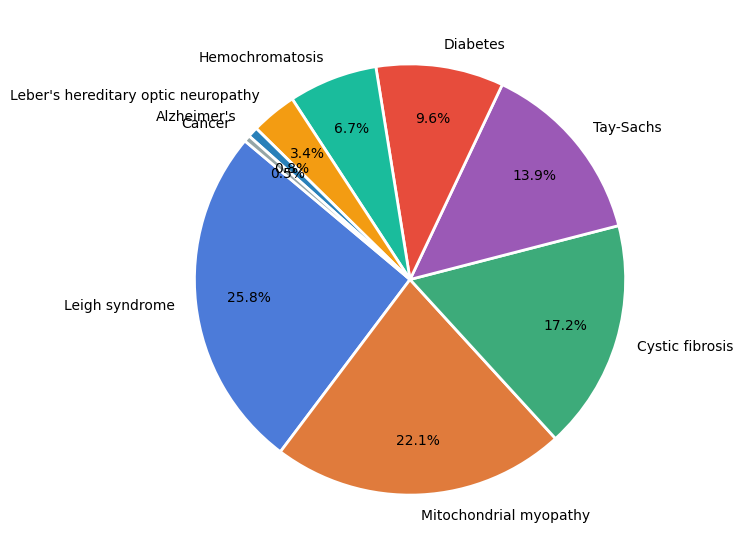

In [ ]:
subclass_counts = data['Disorder Subclass'].value_counts(dropna=True)

colors = ['#4C7BD9','#E07B3C','#3DAB7A','#9B59B6','#E74C3C',
          '#1ABC9C','#F39C12','#2980B9','#95A5A6']

fig, ax = plt.subplots(figsize=(9, 7))

wedges, texts, autotexts = ax.pie(
    subclass_counts,
    labels=subclass_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors[:len(subclass_counts)],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    pctdistance=0.75
)

In [ ]:
data = data[~data['Disorder Subclass'].isin(["Alzheimer's", 'Cancer'])].reset_index(drop=True)

In [ ]:
data['Disorder Subclass'].value_counts()

,count
Disorder Subclass,
Leigh syndrome,2008
Mitochondrial myopathy,1714
Cystic fibrosis,1339
Tay-Sachs,1083
Diabetes,744
Hemochromatosis,518
Leber's hereditary optic neuropathy,267


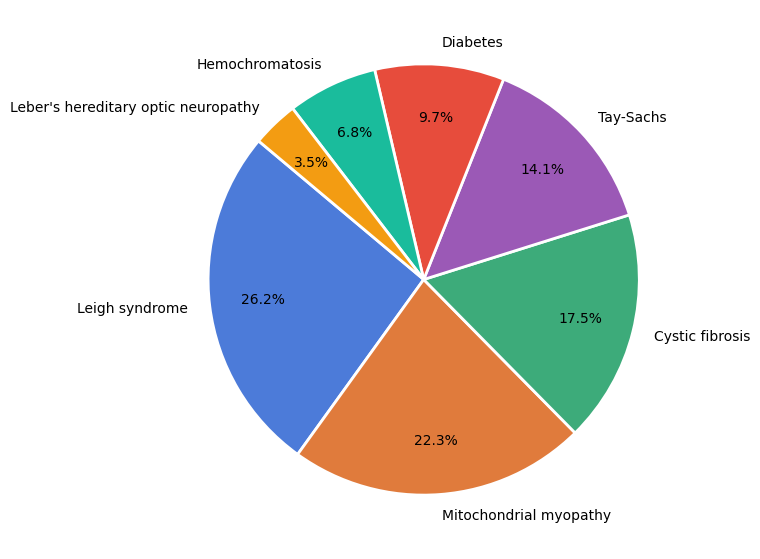

In [ ]:
subclass_counts = data['Disorder Subclass'].value_counts(dropna=True)

colors = ['#4C7BD9','#E07B3C','#3DAB7A','#9B59B6','#E74C3C',
          '#1ABC9C','#F39C12','#2980B9','#95A5A6']

fig, ax = plt.subplots(figsize=(9, 7))

wedges, texts, autotexts = ax.pie(
    subclass_counts,
    labels=subclass_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors[:len(subclass_counts)],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    pctdistance=0.75
)

In [ ]:
#rename )
data.rename(columns={
    'Heart Rate (rates/min': 'Heart Rate (rates/min)'
}, inplace=True)

#Categorical Values Filling

In [ ]:
cat_cols = data.select_dtypes(include='object').columns
print(cat_cols)

Index(['Genes in mother's side', 'Inherited from father', 'Maternal gene',
       'Paternal gene', 'Respiratory Rate (breaths/min)',
       'Heart Rate (rates/min)', 'Parental consent', 'Follow-up', 'Gender',
       'Birth asphyxia', 'Autopsy shows birth defect (if applicable)',
       'Folic acid details (peri-conceptional)',
       'H/O serious maternal illness', 'H/O radiation exposure (x-ray)',
       'H/O substance abuse', 'Assisted conception IVF/ART',
       'History of anomalies in previous pregnancies', 'Birth defects',
       'Blood test result', 'Genetic Disorder', 'Disorder Subclass'],
      dtype='object')


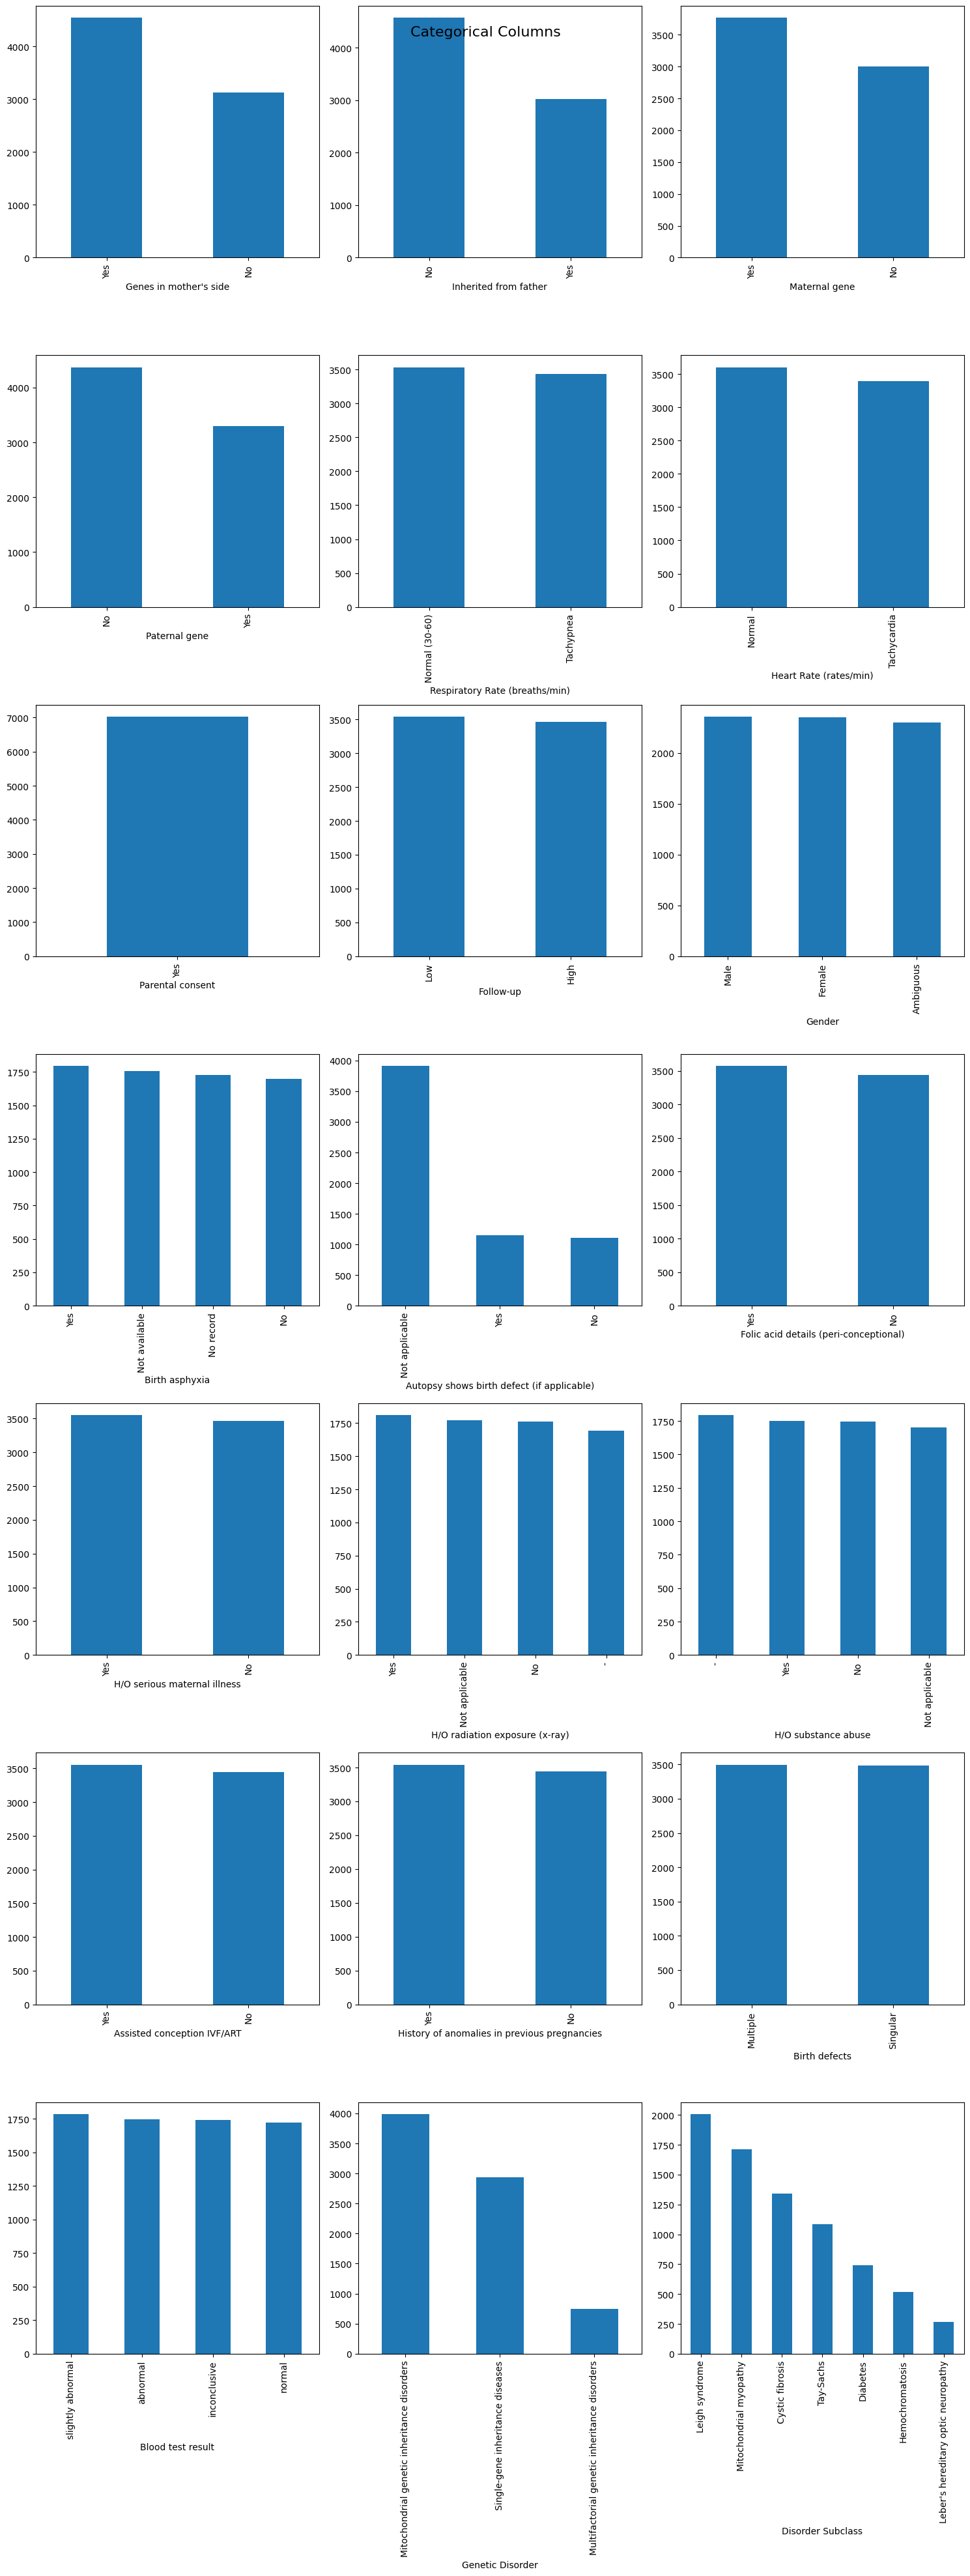

In [ ]:
cat_cols = data.select_dtypes(include='object').columns
fig, axes = plt.subplots(math.ceil(len(cat_cols)/3), 3, figsize=(15, 40))
for i, col in enumerate(cat_cols):
    data[col].value_counts()[:8].plot(kind='bar', ax=axes.flatten()[i])
    plt.suptitle('Categorical Columns', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
data['Blood test result']=data['Blood test result'].fillna(
    data['Blood test result'].mode()[0]
)

In [ ]:
data['Birth defects']=data['Birth defects'].fillna(
    data['Birth defects'].mode()[0]
)

In [ ]:
data['History of anomalies in previous pregnancies']=data['History of anomalies in previous pregnancies'].fillna(
    data['History of anomalies in previous pregnancies'].mode()[0]
)

In [ ]:
data['Assisted conception IVF/ART']=data['Assisted conception IVF/ART'].fillna(
    data['Assisted conception IVF/ART'].mode()[0]
)

In [ ]:
data['H/O substance abuse']=data['H/O substance abuse'].fillna(
    data['H/O substance abuse'].mode()[0]
)

In [ ]:
data['H/O radiation exposure (x-ray)']=data['H/O radiation exposure (x-ray)'].fillna(
    data['H/O radiation exposure (x-ray)'].mode()[0]
)

In [ ]:
data['H/O serious maternal illness']=data['H/O serious maternal illness'].fillna(
    data['H/O serious maternal illness'].mode()[0]
)

In [ ]:
data['Folic acid details (peri-conceptional)']=data['Folic acid details (peri-conceptional)'].fillna(
    data['Folic acid details (peri-conceptional)'].mode()[0]
)

In [ ]:
data['Birth asphyxia']=data['Birth asphyxia'].fillna(
    data['Birth asphyxia'].mode()[0]
)

In [ ]:
data['Gender']=data['Gender'].fillna(
    data['Gender'].mode()[0]
)

In [ ]:
data['Follow-up']=data['Follow-up'].fillna(
    data['Follow-up'].mode()[0]
)

In [ ]:
data['Parental consent']=data['Parental consent'].fillna(
    data['Parental consent'].mode()[0]
)

In [ ]:
data['Heart Rate (rates/min)']=data['Heart Rate (rates/min)'].fillna(
    data['Heart Rate (rates/min)'].mode()[0]
)

In [ ]:
data['Respiratory Rate (breaths/min)']=data['Respiratory Rate (breaths/min)'].fillna(
    data['Respiratory Rate (breaths/min)'].mode()[0]
)

In [ ]:
data['Paternal gene']=data['Paternal gene'].fillna(
    data['Paternal gene'].mode()[0]
)

In [ ]:
data['Maternal gene']=data['Maternal gene'].fillna(
    data['Maternal gene'].mode()[0]
)

In [ ]:
data['Inherited from father']=data['Inherited from father'].fillna(
    data['Inherited from father'].mode()[0]
)

In [ ]:
data["Genes in mother's side"]=data["Genes in mother's side"].fillna(
    data["Genes in mother's side"].mode()[0]
)

In [ ]:
data['Respiratory Rate (breaths/min)']=data['Respiratory Rate (breaths/min)'].fillna(
    data['Respiratory Rate (breaths/min)'].mode()[0]
)

In [ ]:
data['Autopsy shows birth defect (if applicable)'] = \
    data['Autopsy shows birth defect (if applicable)'].fillna('Not Performed')

#Numerical Filling

In [ ]:
cat_cols = data.select_dtypes(include='number').columns
print(cat_cols)

Index(['Patient Age', 'Blood cell count (mcL)', 'Mother's age', 'Father's age',
       'No. of previous abortion',
       'White Blood cell count (thousand per microliter)', 'Symptom 1',
       'Symptom 2', 'Symptom 3', 'Symptom 4', 'Symptom 5'],
      dtype='object')


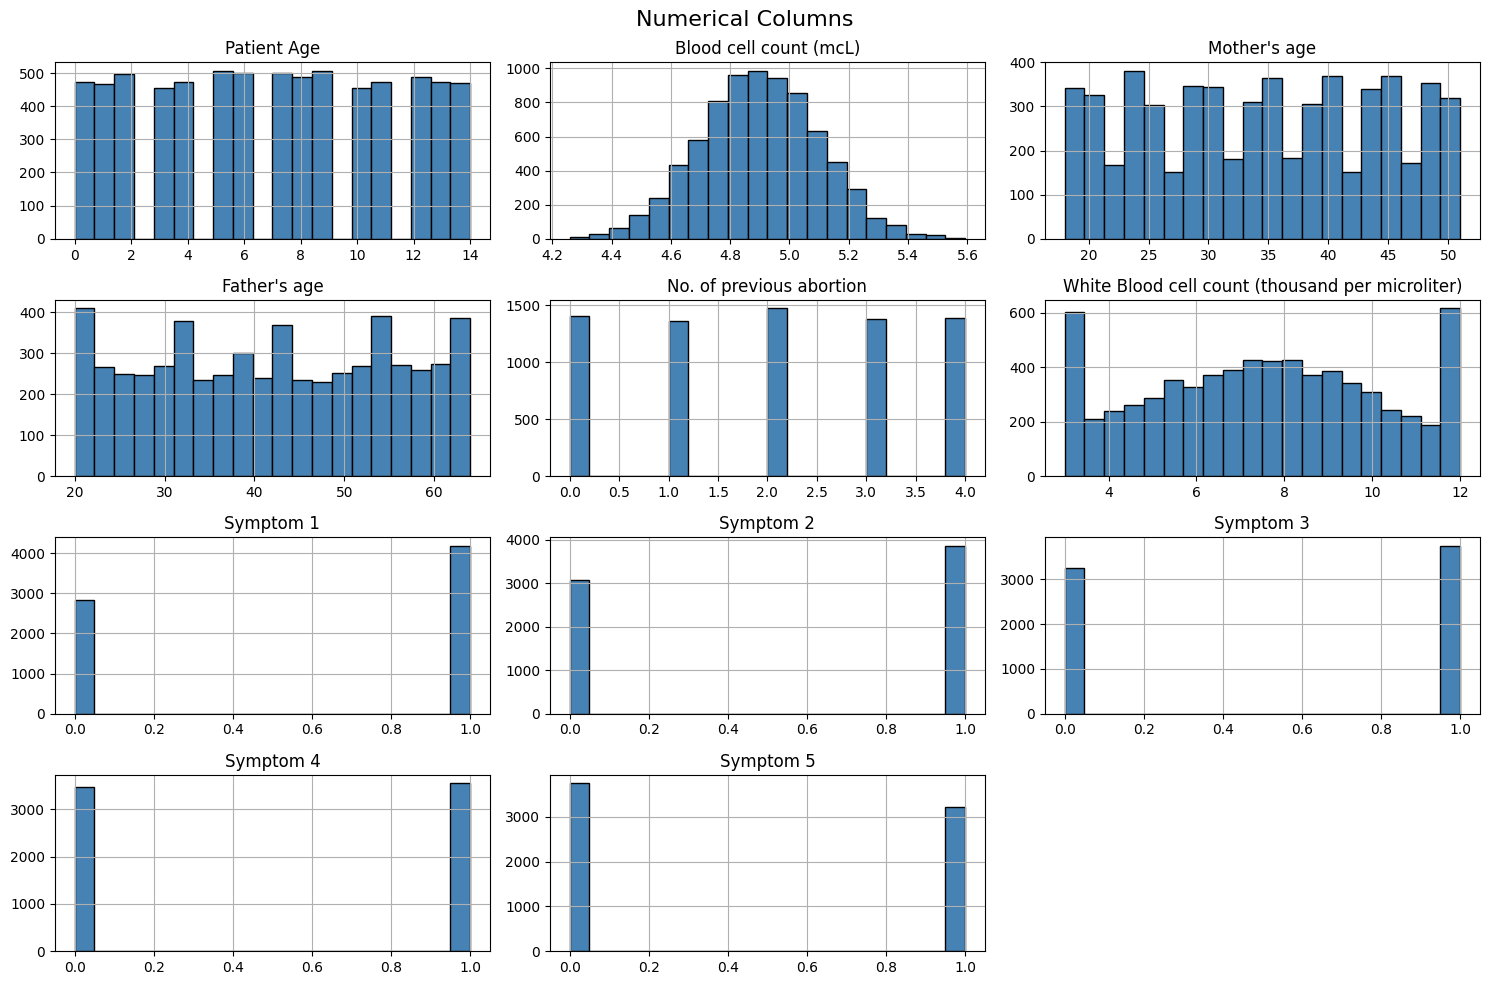

In [ ]:
data.select_dtypes(include='number').hist(figsize=(15, 10), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Numerical Columns', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
data['Patient Age']=data['Patient Age'].fillna(
    data['Patient Age'].median()
)

In [ ]:
data['Blood cell count (mcL)']=data['Blood cell count (mcL)'].fillna(
    data['Blood cell count (mcL)'].median()
)

In [ ]:
data["Mother's age"]=data["Mother's age"].fillna(
    data["Mother's age"].median()
)

In [ ]:
data["Father's age"]=data["Father's age"].fillna(
    data["Father's age"].median()
)

In [ ]:
data['No. of previous abortion']=data['No. of previous abortion'].fillna(
    data['No. of previous abortion'].median()
)

In [ ]:
data['White Blood cell count (thousand per microliter)']=data['White Blood cell count (thousand per microliter)'].fillna(
    data['White Blood cell count (thousand per microliter)'].median()
)

In [ ]:
data['Symptom 1']=data['Symptom 1'].fillna(
    data['Symptom 1'].median()
)


In [ ]:
data['Symptom 2']=data['Symptom 2'].fillna(
    data['Symptom 2'].median()
)

In [ ]:
data['Symptom 3']=data['Symptom 3'].fillna(
    data['Symptom 3'].median()
)

In [ ]:
data['Symptom 4']=data['Symptom 4'].fillna(
    data['Symptom 4'].median()
)

In [ ]:
data['Symptom 5']=data['Symptom 5'].fillna(
    data['Symptom 5'].median()
)

In [ ]:
data.isna().sum()

,0
Patient Age,0
Genes in mother's side,0
Inherited from father,0
Maternal gene,0
Paternal gene,0
Blood cell count (mcL),0
Mother's age,0
Father's age,0
Respiratory Rate (breaths/min),0
Heart Rate (rates/min),0


#Encoding

In [ ]:
#split x nd y
x = data.drop('Disorder Subclass', axis=1)
y = data['Disorder Subclass']

In [ ]:
#one hot encoding
x = pd.get_dummies(x, drop_first=True)

In [ ]:
x.dtypes.value_counts()

,count
bool,31
float64,11


In [ ]:
x = x.astype(float)

In [ ]:
x.dtypes.value_counts()

,count
float64,42


In [ ]:
pd.DataFrame(x).head()

,Patient Age,Blood cell count (mcL),Mother's age,Father's age,No. of previous abortion,White Blood cell count (thousand per microliter),Symptom 1,Symptom 2,Symptom 3,Symptom 4,...,H/O substance abuse_Not applicable,H/O substance abuse_Yes,Assisted conception IVF/ART_Yes,History of anomalies in previous pregnancies_Yes,Birth defects_Singular,Blood test result_inconclusive,Blood test result_normal,Blood test result_slightly abnormal,Genetic Disorder_Multifactorial genetic inheritance disorders,Genetic Disorder_Single-gene inheritance diseases
0,12.0,5.056471,34.0,42.0,2.0,6.040263,1.0,1.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.0,5.147776,45.0,41.0,4.0,9.921528,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
2,12.0,4.712113,22.0,55.0,1.0,7.155166,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
3,7.0,4.763315,35.0,42.0,2.0,3.000000,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
4,13.0,4.910266,50.0,22.0,4.0,7.309489,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


#Outliers

In [ ]:
#categorical outliers
for col in data.select_dtypes(include='object').columns:
    rare = data[col].value_counts()[data[col].value_counts() < 100]
    print(f"{col} : {len(rare)}")

Genes in mother's side : 0
Inherited from father : 0
Maternal gene : 0
Paternal gene : 0
Respiratory Rate (breaths/min) : 0
Heart Rate (rates/min) : 0
Parental consent : 0
Follow-up : 0
Gender : 0
Birth asphyxia : 0
Autopsy shows birth defect (if applicable) : 0
Folic acid details (peri-conceptional) : 0
H/O serious maternal illness : 0
H/O radiation exposure (x-ray) : 0
H/O substance abuse : 0
Assisted conception IVF/ART : 0
History of anomalies in previous pregnancies : 0
Birth defects : 0
Blood test result : 0
Genetic Disorder : 0
Disorder Subclass : 0


In [ ]:
num_cols = data.select_dtypes(include='number').columns

In [ ]:
#numerical outliers
for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    print(col, ":", ((data[col] < lower) | (data[col] > upper)).sum())

Patient Age : 0
Blood cell count (mcL) : 45
Mother's age : 0
Father's age : 0
No. of previous abortion : 0
White Blood cell count (thousand per microliter) : 0
Symptom 1 : 0
Symptom 2 : 0
Symptom 3 : 0
Symptom 4 : 0
Symptom 5 : 0


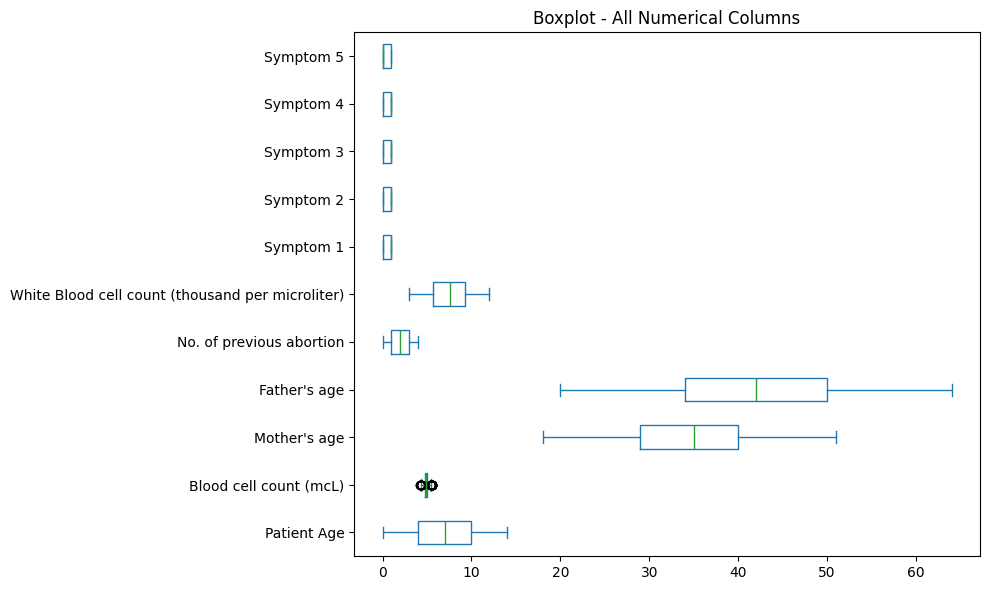

In [ ]:
#outliers visualized
fig, ax = plt.subplots(figsize=(10, 6))
data[num_cols].plot(kind='box', ax=ax, vert=False)
ax.set_title('Boxplot - All Numerical Columns')
plt.tight_layout()
plt.show()

In [ ]:
#iqr/clipping method
for col in ['Blood cell count (mcL)']:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data[col] = data[col].clip(lower, upper)

In [ ]:
for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    print(col, ":", ((data[col] < lower) | (data[col] > upper)).sum())

Patient Age : 0
Blood cell count (mcL) : 0
Mother's age : 0
Father's age : 0
No. of previous abortion : 0
White Blood cell count (thousand per microliter) : 0
Symptom 1 : 0
Symptom 2 : 0
Symptom 3 : 0
Symptom 4 : 0
Symptom 5 : 0


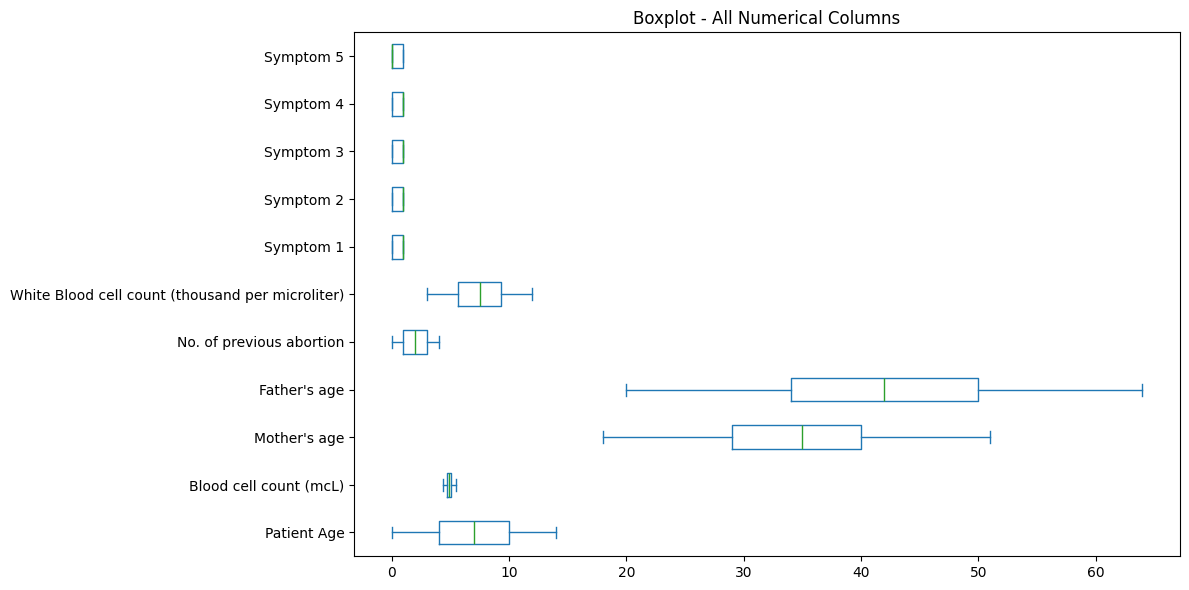

In [ ]:
#After handling outliers
fig, ax = plt.subplots(figsize=(12, 6))

data[num_cols].plot(kind='box', ax=ax, vert=False)
ax.set_title('Boxplot - All Numerical Columns')

plt.tight_layout()
plt.show()

#Scaling

In [ ]:
pd.DataFrame(x).describe().round(2)

,Patient Age,Blood cell count (mcL),Mother's age,Father's age,No. of previous abortion,White Blood cell count (thousand per microliter),Symptom 1,Symptom 2,Symptom 3,Symptom 4,...,H/O substance abuse_Not applicable,H/O substance abuse_Yes,Assisted conception IVF/ART_Yes,History of anomalies in previous pregnancies_Yes,Birth defects_Singular,Blood test result_inconclusive,Blood test result_normal,Blood test result_slightly abnormal,Genetic Disorder_Multifactorial genetic inheritance disorders,Genetic Disorder_Single-gene inheritance diseases
count,7673.00,7673.00,7673.00,7673.0,7673.00,7673.00,7673.00,7673.00,7673.00,7673.00,...,7673.00,7673.00,7673.00,7673.00,7673.00,7673.00,7673.00,7673.00,7673.0,7673.00
mean,7.00,4.90,34.66,42.0,2.00,7.50,0.63,0.60,0.58,0.55,...,0.22,0.23,0.55,0.55,0.45,0.23,0.22,0.32,0.1,0.38
std,4.16,0.20,8.50,11.4,1.35,2.53,0.48,0.49,0.49,0.50,...,0.42,0.42,0.50,0.50,0.50,0.42,0.42,0.47,0.3,0.49
min,0.00,4.26,18.00,20.0,0.00,3.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00
25%,4.00,4.76,29.00,34.0,1.00,5.66,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00
50%,7.00,4.90,35.00,42.0,2.00,7.53,1.00,1.00,1.00,1.00,...,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.0,0.00
75%,10.00,5.03,40.00,50.0,3.00,9.30,1.00,1.00,1.00,1.00,...,0.00,0.00,1.00,1.00,1.00,0.00,0.00,1.00,0.0,1.00
max,14.00,5.59,51.00,64.0,4.00,12.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.0,1.00


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
#Split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)
#Scale
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
pd.DataFrame(x_train).describe().round(2)

,0,1,2,3,4,5,6,7,8,9,...,32,33,34,35,36,37,38,39,40,41
count,6138.00,6138.00,6138.00,6138.00,6138.00,6138.00,6138.00,6138.00,6138.00,6138.00,...,6138.00,6138.00,6138.00,6138.00,6138.00,6138.00,6138.00,6138.00,6138.00,6138.00
mean,0.00,-0.00,-0.00,0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,...,0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.67,-3.09,-1.98,-1.93,-1.49,-1.77,-1.31,-1.22,-1.17,-1.10,...,-0.53,-0.55,-1.10,-1.10,-0.92,-0.54,-0.54,-0.69,-0.33,-0.78
25%,-0.72,-0.70,-0.68,-0.70,-0.75,-0.73,-1.31,-1.22,-1.17,-1.10,...,-0.53,-0.55,-1.10,-1.10,-0.92,-0.54,-0.54,-0.69,-0.33,-0.78
50%,0.00,0.01,0.03,0.01,-0.00,0.02,0.76,0.82,0.86,0.91,...,-0.53,-0.55,0.91,0.91,-0.92,-0.54,-0.54,-0.69,-0.33,-0.78
75%,0.72,0.67,0.62,0.71,0.74,0.70,0.76,0.82,0.86,0.91,...,-0.53,-0.55,0.91,0.91,1.09,-0.54,-0.54,1.45,-0.33,1.28
max,1.68,3.19,1.91,1.94,1.48,1.79,0.76,0.82,0.86,0.91,...,1.89,1.83,0.91,0.91,1.09,1.84,1.87,1.45,3.05,1.28


#Modeling

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import ShuffleSplit


Random Forest

In [ ]:
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf, average='weighted'):.4f}")

Accuracy: 0.7055
Recall: 0.7055


Logistic Regression

In [ ]:
lr = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
lr.fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr, average='weighted'):.4f}")

Accuracy: 0.7088
Recall: 0.7088


Decision Tree

In [ ]:
dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt.fit(x_train, y_train)
y_pred_dt = dt.predict(x_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_dt, average='weighted'):.4f}")


Accuracy: 0.6326
Recall: 0.6326


Gradient Boosting

In [ ]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(x_train, y_train)
y_pred_gb = gb.predict(x_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_gb, average='weighted'):.4f}")


Accuracy: 0.7225
Recall: 0.7225


Precision, Recall, F1 Score

In [ ]:
p = precision_score(y_test, y_pred_gb, average='weighted')
r = recall_score(y_test, y_pred_gb, average='weighted')
f = f1_score(y_test, y_pred_gb, average='weighted')
print(f"Precision={p:.4f} | Recall={r:.4f} ,F1={f:.4f}")

Precision=0.7157 | Recall=0.7225 ,F1=0.7137


Confusion Matrix

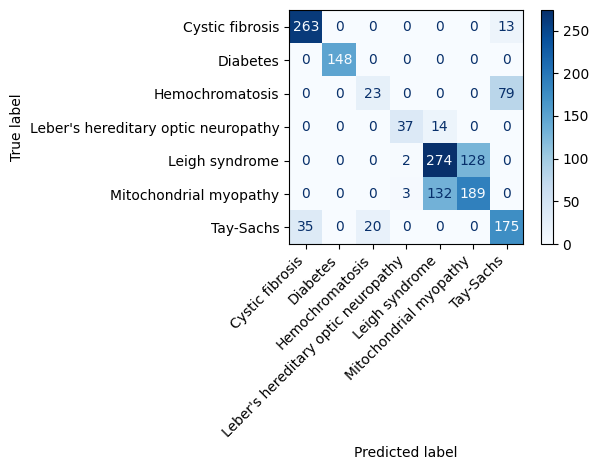

In [ ]:
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_gb, cmap='Blues')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Classification Report

In [ ]:
print(classification_report(y_test, y_pred_gb))

                                     precision    recall  f1-score   support

                    Cystic fibrosis       0.88      0.95      0.92       276
                           Diabetes       1.00      1.00      1.00       148
                    Hemochromatosis       0.53      0.23      0.32       102
Leber's hereditary optic neuropathy       0.88      0.73      0.80        51
                     Leigh syndrome       0.65      0.68      0.67       404
             Mitochondrial myopathy       0.60      0.58      0.59       324
                          Tay-Sachs       0.66      0.76      0.70       230

                           accuracy                           0.72      1535
                          macro avg       0.74      0.70      0.71      1535
                       weighted avg       0.72      0.72      0.71      1535



ROC-AUC Score, Graph

ROC-AUC Score: 0.9395


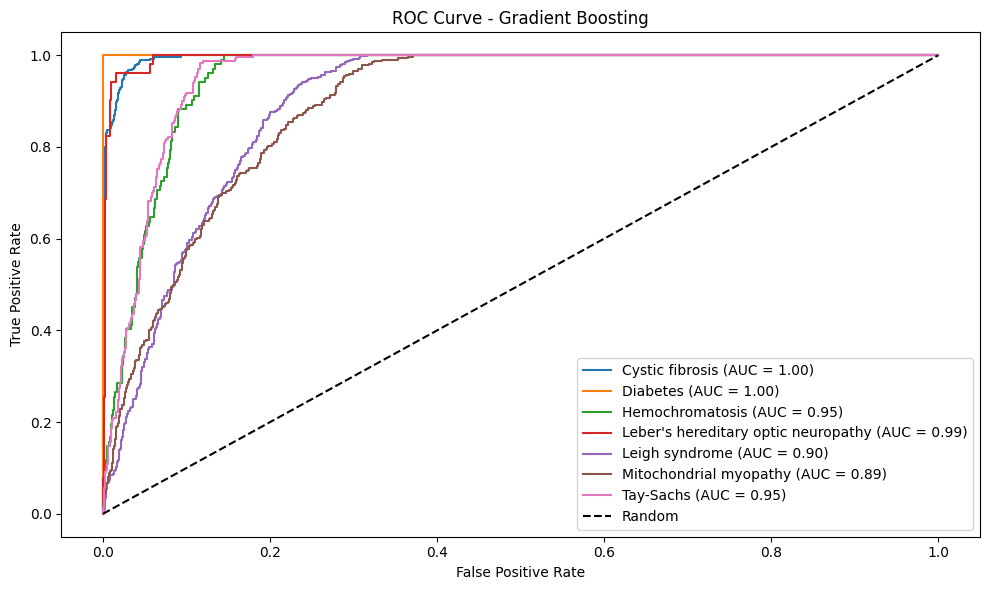

In [ ]:


# ROC-AUC Score
auc_score = roc_auc_score(y_test, gb.predict_proba(x_test), average='weighted', multi_class='ovr')
print(f"ROC-AUC Score: {auc_score:.4f}")

# Binarize the output
classes = gb.classes_
y_test_bin = label_binarize(y_test, classes=classes)
y_prob = gb.predict_proba(x_test)

# Plot ROC curve for each class
fig, ax = plt.subplots(figsize=(10, 6))

for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{cls} (AUC = {roc_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - Gradient Boosting')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

Cross Validation

In [ ]:
scores = cross_val_score(gb, x_train, y_train, cv=5, scoring='accuracy')
print(f"Mean Accuracy: {scores.mean():.4f}")
print(f"Standard Deviation: {scores.std():.4f}")
print(f"All Scores: {scores}")

Mean Accuracy: 0.7019
Standard Deviation: 0.0155
All Scores: [0.70684039 0.72557003 0.69788274 0.67726161 0.70171149]


Shuffled Test

In [ ]:
ss = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
scores = cross_val_score(gb, x_train, y_train, cv=ss, scoring='accuracy')
print(f"Mean Accuracy: {scores.mean():.4f}")
print(f"Standard Deviation: {scores.std():.4f}")
print(f"All Scores: {scores}")

Mean Accuracy: 0.6953
Standard Deviation: 0.0152
All Scores: [0.69299674 0.66856678 0.70928339 0.69462541 0.71091205]


Data Leakage Test

In [ ]:
# Train accuracy
y_train_pred = gb.predict(x_train)
train_acc = accuracy_score(y_train, y_train_pred)
# Test accuracy
test_acc = accuracy_score(y_test, y_pred_gb)
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Difference: {abs(train_acc - test_acc):.4f}")

Train Accuracy: 0.8068
Test Accuracy: 0.7225
Difference: 0.0843


#deployment

In [ ]:
from sklearn.preprocessing import LabelEncoder
import joblib
joblib.dump(gb, 'genetic_disorder_model.pkl')
joblib.dump(list(x.columns), 'model_columns.pkl')
label_encoders = {}
cat_cols = data.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    if col not in ['Genetic Disorder', 'Disorder Subclass']:
        le = LabelEncoder()
        le.fit(data[col].astype(str))
        label_encoders[col] = le

joblib.dump(label_encoders, 'label_encoders.pkl')

print("Saved: model, columns, label_encoders")

Saved: model, columns, label_encoders


In [ ]:
from google.colab import files

joblib.dump(scaler, 'scaler.pkl')
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Save scaler
joblib.dump(scaler, 'scaler.pkl')
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install streamlit pyngrok joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 113.1 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

st.set_page_config(page_title="Genetic Disorder Predictor", page_icon="🧬", layout="wide")

st.markdown("""
    <style>
    @import url('https://fonts.googleapis.com/css2?family=DM+Serif+Display&family=DM+Sans:wght@300;400;500&display=swap');
    html, body, [class*="css"] { font-family: 'DM Sans', sans-serif; }
    h1, h2, h3 { font-family: 'DM Serif Display', serif; }
    .main { background-color: #f0f4f8; }
    .stButton>button {
        background-color: #1a1a2e; color: white;
        border-radius: 8px; padding: 0.6em 2em;
        font-size: 16px; border: none; width: 100%;
    }
    .stButton>button:hover { background-color: #16213e; }
    .result-box {
        background-color: #1a1a2e; color: white;
        padding: 2rem; border-radius: 12px;
        text-align: center; margin-top: 1rem;
    }
    .result-box h2 { color: #00d4aa; font-size: 1.2rem; margin-bottom: 0.2rem; }
    .result-box h1 { color: white; font-size: 1.8rem; margin-bottom: 1rem; }
    .divider { border-top: 1px solid #ffffff33; margin: 1rem 0; }
    </style>
""", unsafe_allow_html=True)

@st.cache_resource
def load_model():
    model = joblib.load('/content/genetic_disorder_model.pkl')
    columns = joblib.load('/content/model_columns.pkl')
    label_encoders = joblib.load('/content/label_encoders.pkl')
    return model, columns, label_encoders

model, model_columns, label_encoders = load_model()

disorder_map = {
    'Leigh syndrome': 'Mitochondrial genetic inheritance disorders',
    'Mitochondrial myopathy': 'Mitochondrial genetic inheritance disorders',
    'Cystic fibrosis': 'Single-gene inheritance diseases',
    'Tay-Sachs': 'Single-gene inheritance diseases',
    'Hemochromatosis': 'Single-gene inheritance diseases',
    "Leber's hereditary optic neuropathy": 'Single-gene inheritance diseases',
    'Diabetes': 'Multifactorial genetic inheritance disorders'
}

st.markdown("<h1 style='text-align:center;'>🧬 Genetic Disorder Predictor</h1>", unsafe_allow_html=True)
st.markdown("<p style='text-align:center; color:gray;'>Enter patient details below to predict the genetic disorder subclass</p>", unsafe_allow_html=True)
st.markdown("---")

col1, col2, col3 = st.columns(3)

with col1:
    st.subheader("👤 Patient Info")
    patient_age = st.number_input("Patient Age", min_value=0, max_value=120, value=None, placeholder="Enter age")
    gender = st.selectbox("Gender", ["", "Male", "Female", "Ambiguous"])
    blood_cell = st.number_input("Blood Cell Count (mcL)", min_value=0.0, value=None, placeholder="e.g. 5000.0")
    wbc = st.number_input("White Blood Cell Count (thousand/µL)", min_value=0.0, value=None, placeholder="e.g. 7.0")
    symptom1 = st.number_input("Symptom 1", min_value=0, max_value=10, value=None, placeholder="0–10")
    symptom2 = st.number_input("Symptom 2", min_value=0, max_value=10, value=None, placeholder="0–10")
    symptom3 = st.number_input("Symptom 3", min_value=0, max_value=10, value=None, placeholder="0–10")
    symptom4 = st.number_input("Symptom 4", min_value=0, max_value=10, value=None, placeholder="0–10")
    symptom5 = st.number_input("Symptom 5", min_value=0, max_value=10, value=None, placeholder="0–10")

with col2:
    st.subheader("👨‍👩‍👧 Family Info")
    mothers_age = st.number_input("Mother's Age", min_value=0, max_value=100, value=None, placeholder="Enter age")
    fathers_age = st.number_input("Father's Age", min_value=0, max_value=100, value=None, placeholder="Enter age")
    genes_mother = st.selectbox("Genes in Mother's Side", ["", "Yes", "No"])
    inherited_father = st.selectbox("Inherited from Father", ["", "Yes", "No"])
    maternal_gene = st.selectbox("Maternal Gene", ["", "Yes", "No"])
    paternal_gene = st.selectbox("Paternal Gene", ["", "Yes", "No"])
    prev_abortions = st.number_input("No. of Previous Abortions", min_value=0, max_value=20, value=None, placeholder="Enter number")
    history_anomalies = st.selectbox("History of Anomalies in Previous Pregnancies", ["", "Yes", "No"])

with col3:
    st.subheader("🏥 Medical History")
    respiratory_rate = st.selectbox("Respiratory Rate (breaths/min)", ["", "Normal (30-60)", "Tachypnea"])
    heart_rate = st.selectbox("Heart Rate (rates/min)", ["", "Normal", "Tachycardia"])
    parental_consent = st.selectbox("Parental Consent", ["Yes"])
    follow_up = st.selectbox("Follow-up", ["", "Low", "High"])
    birth_asphyxia = st.selectbox("Birth Asphyxia", ["", "No", "Yes", "No record", "Not available"])
    autopsy = st.selectbox("Autopsy Shows Birth Defect", ["", "Not applicable", "No", "Not Performed", "Yes"])
    folic_acid = st.selectbox("Folic Acid Details (peri-conceptional)", ["", "Yes", "No"])
    maternal_illness = st.selectbox("H/O Serious Maternal Illness", ["", "Yes", "No"])
    radiation = st.selectbox("H/O Radiation Exposure (x-ray)", ["", "Not applicable", "Yes", "No", "-"])
    substance_abuse = st.selectbox("H/O Substance Abuse", ["", "-", "No", "Yes", "Not applicable"])
    ivf = st.selectbox("Assisted Conception IVF/ART", ["", "Yes", "No"])
    birth_defects = st.selectbox("Birth Defects", ["", "Multiple", "Singular"])
    blood_test = st.selectbox("Blood Test Result", ["", "slightly abnormal", "abnormal", "normal", "inconclusive"])

st.markdown("---")

if st.button("🔍 Predict Genetic Disorder"):
    empty_fields = [
        patient_age is None, gender == "", blood_cell is None, wbc is None,
        mothers_age is None, fathers_age is None, genes_mother == "",
        inherited_father == "", maternal_gene == "", paternal_gene == "",
        prev_abortions is None, history_anomalies == "", respiratory_rate == "",
        heart_rate == "", follow_up == "", birth_asphyxia == "", autopsy == "",
        folic_acid == "", maternal_illness == "", radiation == "",
        substance_abuse == "", ivf == "", birth_defects == "", blood_test == "",
        symptom1 is None, symptom2 is None, symptom3 is None,
        symptom4 is None, symptom5 is None,
    ]

    if any(empty_fields):
        st.warning("⚠️ Please fill in all fields before predicting.")
    else:
        input_dict = {
            'Patient Age': patient_age,
            "Genes in mother's side": genes_mother,
            'Inherited from father': inherited_father,
            'Maternal gene': maternal_gene,
            'Paternal gene': paternal_gene,
            'Blood cell count (mcL)': blood_cell,
            "Mother's age": mothers_age,
            "Father's age": fathers_age,
            'Respiratory Rate (breaths/min)': respiratory_rate,
            'Heart Rate (rates/min)': heart_rate,
            'Parental consent': parental_consent,
            'Follow-up': follow_up,
            'Gender': gender,
            'Birth asphyxia': birth_asphyxia,
            'Autopsy shows birth defect (if applicable)': autopsy,
            'Folic acid details (peri-conceptional)': folic_acid,
            'H/O serious maternal illness': maternal_illness,
            'H/O radiation exposure (x-ray)': radiation,
            'H/O substance abuse': substance_abuse,
            'Assisted conception IVF/ART': ivf,
            'History of anomalies in previous pregnancies': history_anomalies,
            'No. of previous abortion': prev_abortions,
            'Birth defects': birth_defects,
            'White Blood cell count (thousand per microliter)': wbc,
            'Blood test result': blood_test,
            'Symptom 1': symptom1,
            'Symptom 2': symptom2,
            'Symptom 3': symptom3,
            'Symptom 4': symptom4,
            'Symptom 5': symptom5,
        }

        input_df = pd.DataFrame([input_dict])
        for col in input_df.select_dtypes(include='object').columns:
            if col in label_encoders:
                le = label_encoders[col]
                val = input_df[col].astype(str).iloc[0]
                if val in le.classes_:
                    input_df[col] = le.transform([val])
                else:
                    input_df[col] = le.transform([le.classes_[0]])

        input_df = input_df.reindex(columns=model_columns, fill_value=0)

        prediction = model.predict(input_df)[0]
        genetic_disorder_type = disorder_map.get(prediction, 'Unknown')

        st.markdown(f"""
            <div class="result-box">
                <h2>🧬 Genetic Disorder</h2>
                <h1>{genetic_disorder_type}</h1>
                <div class="divider"></div>
                <h2>🔬 Disorder Subclass</h2>
                <h1>{prediction}</h1>
            </div>
        """, unsafe_allow_html=True)

Writing app.py


In [ ]:
from pyngrok import ngrok
import subprocess
import time

ngrok.set_auth_token("3D9RFzCWuYtnN9eGJbsBP4OXXvK_4Sru12FVqVcSPJTYvf39C")

ngrok.kill()
time.sleep(1) # Add a small delay after killing ngrok processes

process = subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501"])

time.sleep(3)

public_url = ngrok.connect(8501)
print("🌐 Your app is live at:", public_url)

🌐 Your app is live at: NgrokTunnel: "https://guidable-dedicator-unveiling.ngrok-free.dev" -> "http://localhost:8501"
